# А/В-тесты для бизнес-решений: от гипотезы до роста выручки

<a id=content></a>
### Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
    <br>[1.1. Предварительная обработка данных](#1.1.)
    <br>[1.2. Преобразование типов данных](#1.2.)
    <br>[1.3. Выявление пропусков](#1.3.)
    <br>[1.4. Выявление дубликатов](#1.4.)
2. [<b>Приоритизация гипотез</b>](#2)
    <br>[2.1. Метод приоритизации ICE](#2.1.)
    <br>[2.2. Метод приоритизации RICE](#2.2.)
3. [<b>Анализ A/B-теста</b>](#3)
    <br>[3.1. Кумулятивная выручка по группам: график, выводы, предположения](#3.1.)
    <br>[3.2. Кумулятивный средний чек по группам: график, выводы, предположения](#3.2.)
    <br>[3.3. Относительное изменение кумулятивного среднего чека группы B к группе A: график, выводы, предположения](#3.3.)
    <br>[3.4. Кумулятивное среднее количество заказов на посетителя по группам: график, выводы, предположения](#3.4.)
    <br>[3.5. Относительное изменение кумулятивного среднего количества заказов на посетителя группы B к группе A: график, выводы, предположения](#3.5.)
    <br>[3.6. Количество заказов по пользователям](#3.6.)
    <br>[3.7. Граница для определения аномалий по количеству заказов на пользователя](#3.7.)
    <br>[3.8. Стоимости заказов пользователей](#3.8.)
    <br>[3.9. Граница для определения аномалий по стоимости заказов](#3.9.)
    <br>[3.10. Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным](#3.10.)
    <br>[3.11. Статистическая значимость различий в среднем чеке заказа между группами по «сырым» данным¶](#3.11.)
    <br>[3.12. Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным](#3.12.)
    <br>[3.13. Статистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным¶](#3.13.)
5. [<b>Принятое решение по результатам теста и его аргументация</b>](#4)
6. [<b>Вывод</b>](#5)

<a id=descr_proj></a>
## Описание проекта
Выступая в роли аналитика крупного интернет-магазина, нами совместно с отделом маркетинга был подготовлен список гипотез для увеличения выручки. Предстоит приоритизировать гипотезы, запустить А/В тест и проанализировать полученные результаты. Проектная работа состоит из двух частей: 1) приоритизация гипотез; 2) анализ A/B-теста.

<a id=descr_data></a>
## Описание данных
В работу поступило три датафрейма, в их числе датафрейм `hypothesis.csv` для первой части исследования, посвящённой приоритизации гипотез, а также датафреймы `orders.csv` и `visitors.csv` непосредственно для второй части исследования, включающей анализ результатов A/B-теста.

*Таблица 1. Структура исходных данных*

<br><b>Наименование датафрейма:</b> `hypothesis.csv`
<br><b>Размер датафрейма:</b> 9 строк х 5 столбцов

|№ п/п|Наименование признака|Описание признака|Единицы измерения|Размах значений|
|------|:----------------------|:------------------|:------------------|:------------------|
|1.|`Hypothesis`|формулировка гипотезы| 9 уникальных формулировок гипотез |0. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей; <br>1. Запустить собственную службу доставки, что сократит срок доставки заказов; <br>2. Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа; <br>3. Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар; <br>4. Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей; <br>5. Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов; <br>6. Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию; <br>7. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок; <br>8. Запустить акцию, дающую скидку на товар в день рождения|
|2.|`Reach`|охват пользователей|баллы|от 1 до 10|
|3.|`Impact`|влияние на пользователей|баллы|от 1 до 10|
|4.|`Confidence`|уверенность в гипотезе|баллы|от 1 до 10|
|5.|`Efforts`|затраты ресурсов на проверку гипотезы|баллы|от 1 до 10|

<br><b>Наименование датафрейма:</b> `orders.csv`
<br><b>Размер датафрейма:</b> 1197 строк х 5 столбцов

|№ п/п|Наименование признака|Описание признака|Единицы измерения|Размах значений|
|-----|:--------------------|:----------------|:----------------|:--------------|
|1.|`transactionId`|идентификатор заказа|1197 уникальных значений идентификаторов заказов|от 1062393 до 4293855558 |
|2.|`visitorId`|идентификатор пользователя, совершившего заказ|уникальных значений идентификаторов пользователей| от 5114589 до 4283872382|
|3.|`date`|календарная дата заказа|день|от 2019-08-01 до 2019-08-31|
|4.|`revenue`|выручка заказа|денежные единицы|от 50 до 1294500|
|5.|`group`|группа A/B-теста, в которую попал заказ|наименование группы|`A`, `B`|

<br><b>Наименование датафрейма:</b> `visitors.csv`
<br><b>Размер датафрейма:</b> 62 строки х 3 столбца

|№ п/п|Наименование признака|Описание признака|Единицы измерения|Размах значений|
|-----|:--------------------|:----------------|:----------------|:--------------|
|1.|`date`|календарная дата посещения|день|от 2019-08-01 до 2019-08-31|
|2.|`group`|группа A/B-теста|наименование группы|`A`, `B`|
|3.|`visitors`|количество пользователей в указанную дату в указанной группе A/B-теста|человек|от 361 до 770|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к вышеперечисленным датафреймам.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации
Загрузим данные о гипотезах, заказах и покупателях из CSV-файлов в переменные. Рассмотрим данные и выполним предобработку, а также выявим возможное наличие пропусков, дубликатов. Выполним проверку на соответствие типов данных и сохранённых в них значениях.

In [1]:
# импорт библиотек
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None) # устанавливаем опцию вывода всех столбцов
pd.set_option('display.max_colwidth', None) # устанавливаем опцию вывода максимальной ширины столбцов
pd.options.display.float_format ='{:.2f}'.format # устанавливаем форматирование отображения чисел типа float с двумя знаками после запятой

# игнорирование системных предупреждений об обновлениях работы функций
import warnings
warnings.simplefilter('ignore')

# настройка вывода визуализации
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
from pylab import rcParams
rcParams['figure.figsize'] = 12,6
sns.set_style('whitegrid', {'axes.grid' : True})

In [2]:
# загрузка файлов в датафреймы
try:
    hypothesis = pd.read_csv('hypothesis.csv', sep=',') # гипотезы
    orders = pd.read_csv('orders.csv', sep=',')         # заказы
    visitors = pd.read_csv('visitors.csv', sep=',')     # посетители
    
except:
    hypothesis = pd.read_csv('https://code.s3.yandex.net/datasets/hypothesis.csv', sep=',')
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders.csv', sep=',')
    visitors = pd.read_csv('https://code.s3.yandex.net/datasets/visitors.csv', sep=',')

In [3]:
# выводим датафреймы для ознакомления: весь датафрейм с гипотезами и по 5 первых строк датафреймов с заказами и посетителями
display(hypothesis.head(10))
display(orders.head())
display(visitors.head())

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [4]:
# выводим основную информацию о количестве записей, количестве ненулевых значений, типах признаков
display(hypothesis.info())
display(orders.info())
display(visitors.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


None

In [5]:
# выводим первичный статистический анализ по заказам и посетителям
display(orders.describe().astype(int))
display(visitors.describe().astype(int))

,transactionId,visitorId,revenue
count,1197,1197,1197
mean,2155621385,2165960143,8348
std,1229084904,1236014192,39191
min,1062393,5114589,50
25%,1166775572,1111826046,1220
50%,2145193898,2217984702,2978
75%,3237740112,3177606451,8290
max,4293855558,4283872382,1294500


,visitors
count,62
mean,607
std,114
min,361
25%,534
50%,624
75%,710
max,770


<a id=1.1.></a>
### 1.1. Предварительная обработка данных

In [6]:
# в датафрейме с гипотезами приводим названия признаков к нижнему регистру
hypothesis.columns = hypothesis.columns.str.lower()

In [7]:
# в датафрейме с заказами приводим наименования признаков к змеиному регистру
orders = orders.rename(columns={'transactionId': 'transaction_id', 'visitorId': 'visitor_id'})

In [8]:
# в датафрейме с гипотезами приводим к единообразию корректное написание термина "интернет-магазин"
# в датафрейме с гипотезами корректирируем склонение слова "структура"
hypothesis.at[2, 'hypothesis'] = 'Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа'
hypothesis.at[3, 'hypothesis'] = 'Изменить структуру категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар'

In [9]:
# выводим названия признаков для ознакомления с результатами преобразований
display(hypothesis.columns)
display(orders.columns)

Index(['hypothesis', 'reach', 'impact', 'confidence', 'efforts'], dtype='object')

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

Предварительным этапом A/B-теста является A/A-тест, успешность которого зависит от следующих критериев:
* Попавший в одну из групп посетитель остаётся в этой группе до конца теста;
* Количество пользователей в различных группах различается не более, чем на 1%;
* Для всех групп фиксируют и отправляют в системы аналитики данные об одном и том же;
* Различие ключевых метрик по группам не превышает 1% и не имеет статистической значимости.

Поскольку, задача анализа A/B-теста была поставлена перед нами постфактум, то, мы можем предположить, что А/А-тест уже состоялся. Следовательно, мы можем проверить актуальные датафреймы на соответствие этим критериям.

In [10]:
# критерий успешности А/А-теста №1
# проверка распределения уникальных пользователей по группам A/B-теста 
users_per_group = orders.groupby('group').agg(count_unique_users = ('visitor_id', 'nunique')).reset_index()
print('Число уникальных пользователей всего:', len(orders.visitor_id.unique()), 'человек.')
print('Распределение числа пользователей по группам A/B-теста:')
users_per_group

Число уникальных пользователей всего: 1031 человек.
Распределение числа пользователей по группам A/B-теста:


,group,count_unique_users
0,A,503
1,B,586


Всего уникальных пользователей в датафрейме `orders.csv` 1031 человек, а сумма представителей групп тестирования A и B равна 1089 человек. Итоговые значения не совпадают, следовательно, мы имеем дело с присутствием 58 пользователей в обеих группах, или пересечением данных. Пересечение групп может повлиять на результаты анализа. В реальной практике тест скорее всего пришлось бы проводить заново. В рамках данного исследовательского проекта в качестве практики можно попробовать исключить таких пользователей из заказов, при этом надо иметь в виду, что корректно исключить их из визитов не получится, так как данные в этом датасете агрегированы.

In [11]:
# применим метод intersection, который вернёт пересечение индексов элементов, общих для обоих массивов данных
group_A = set(orders[orders['group'] == 'A']['visitor_id'])
group_B = set(orders[orders['group'] == 'B']['visitor_id'])
group_AABB = group_A.intersection(group_B)
orders = orders[~orders['visitor_id'].isin(group_AABB)]

In [12]:
# проверка результата вычета пересекающихся значений в датафрейме с заказами
print('Число уникальных пользователей: ', len(orders.visitor_id.unique()), 'человек.')
print('Число пользователей всего: ', len(orders), 'человек.')

Число уникальных пользователей:  973 человек.
Число пользователей всего:  1016 человек.


In [13]:
# критерий успешности А/А-теста №2
# проверка количества уникальных пользователей по группам A/B-теста 
users_per_group = orders.groupby('group').agg(count_unique_users = ('visitor_id', 'nunique')).reset_index()
users_per_group['%'] = (users_per_group['count_unique_users'] * 100 / len(orders.visitor_id.unique())).round(2)
print('Уникальных пользователей всего:', len(orders.visitor_id.unique()), 'человек.')
print('Распределение пользователей по группам A/B-теста:')
users_per_group

Уникальных пользователей всего: 973 человек.
Распределение пользователей по группам A/B-теста:


,group,count_unique_users,%
0,A,445,45.73
1,B,528,54.27


В соответствии с критерием успешности А/А теста №2 количество пользователей в различных группах должно различаться не более, чем на 1%. В датафрейме `orders.csv` после удаления пересекающихся данных по группам A и B мы наблюдаем процентное соотношение пользователей групп A и B в размере 45.73% к 54.27%. Соответственно, **количественное различие пользователей в различных группах A/B-теста составляет 8.5% вместо рекомендованного 1%.** На этом этапе работы мы не можем повлиять на этот критерий и путём рандомного удаления пользователей из многочисленной группы B выровнять соотношение групп. Сохраняем данные в датафрейме в текущем состоянии.

Также, мы не имеем данных о применении критерия успешности А/А-теста №3, согласно которому для всех групп фиксируют и отправляют в системы аналитики данные об одном и том же. Аналогичным образом обстоят дела и с критерием успешности А/А-теста №4, в соответствии с которым различие ключевых метрик по группам не превышает 1% и не имеет статистической значимости. Однако, мы можем рассмореть значения выручки заказа в датафрейме `orders.csv`.

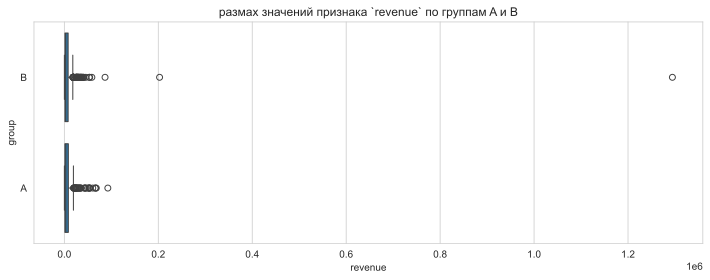

In [14]:
# критерий успешности А/А-теста №4
# диаграмма размаха значений признака `revenue`
plt.figure(figsize=(12,4))
plt.title('размах значений признака `revenue` по группам A и B')
sns.boxplot(data=orders, x='revenue', y='group');

На диаграмме размаха отчётливо видны аномальные данные, расположенные над границей верхнего уса. Чтобы лучше изучить медианные значения, установим параметр `xlim` равным 20 000. 

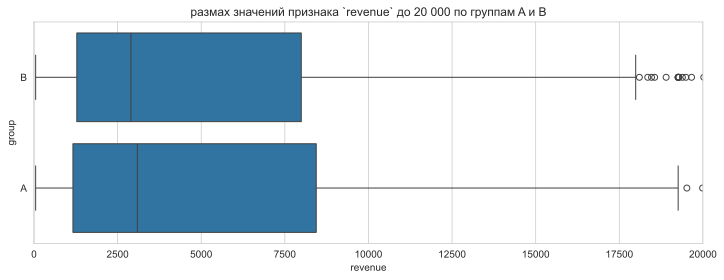

In [15]:
# диаграмма размаха значений признака `revenue`
plt.figure(figsize=(12,4))
plt.title('размах значений признака `revenue` до 20 000 по группам A и B')
plt.xlim([0, 20000])
sns.boxplot(data=orders, x='revenue', y='group');

*Таблица 3. Агрегированные статистические значения признака 'revenue' по группам A и B*

|Наименование группы|min значение выручки|mean значение выручки|median значение выручки|Q3|Q99|Q100|Порог аномальных значений|
|:-|:-|:-|:-|:-|:-|:-|:-|
|Группа А|50|7189|3090|8438|56064|92550|19349|
|Группа B|50|9249|2898|7991|49553|1294500|18057|

Существенная разница между средними и медианными значениями свидетельствует о неоднородности данных и присутствии большого количества аномальных значений по признаку 'revenue' в обеих группах.

В группе A к аномальным стоимостным значениям относятся 35 строк, в группе B таких аномальных значений почти в 2 раза больше, и их число равно 53. Сортировка значений признака 'revenue' по группам A и B подтверждает статистические расчёты, а именно: в группе B присутствуют две строки с аномальными значениями, существенно искажающими данные для анализа.

In [16]:
# сортировка значений признака 'revenue' по группе A
orders[orders['group'] == 'A']['revenue'].sort_values(ascending=False)

1136    92550
743     67990
1103    66350
1099    65710
949     60450
        ...  
54        100
996       100
878        90
307        76
584        50
Name: revenue, Length: 468, dtype: int64

In [17]:
# сортировка значений признака 'revenue' по группе B
orders[orders['group'] == 'B']['revenue'].sort_values(ascending=False)

425     1294500
1196     202740
744       86620
940       58550
613       53904
         ...   
908          75
404          70
933          60
756          50
459          50
Name: revenue, Length: 548, dtype: int64

In [18]:
# удалим две строки с аномальными данными признака 'revenue' по группе B
# orders = orders.drop(index=[425,1196])

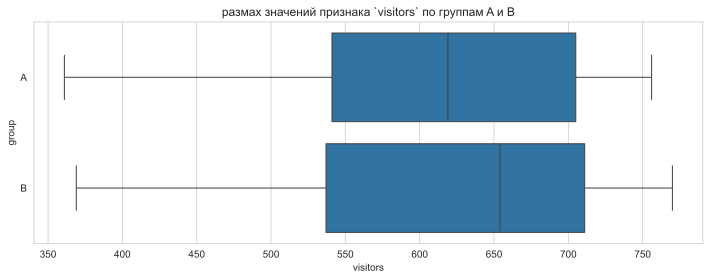

In [19]:
# критерий успешности А/А-теста №4
# диаграмма размаха значений признака `visitors`
plt.figure(figsize=(12,4))
plt.title('размах значений признака `visitors` по группам A и B')
sns.boxplot(data=visitors, x='visitors', y='group');

Значения признака 'visitors' в датафрейме `visitors.csv` достаточно сбалансированные по обеим группам. Это также подтверждается статистическими расчётами: среднее и медианное количество посетителей в группе A равно 604 и 619 человек соответственно, в группе B - 610 и 654 человека соответственно. Медианное значение количества посетилей в группе B больше, чем в группе А.

<a id=1.2.></a>
### 1.2. Преобразование типов данных

*Таблица 2. Перечень признаков в разрезе датафреймов, подлежащих преобразованию*

|Наименование датафрейма|Наименование признака|Описание признака|Текущий тип данных|Требуемый тип данных|
|-----------------------|:--------------------|:----------------|:-----------------|:-------------------|
|`orders`|date|календарная дата заказа|object|datetime|
|`visitors`|date|календарная дата посещения|object|datetime|

In [20]:
# преобразуем данные о времени
orders['date'] = pd.to_datetime(orders['date'])
visitors['date'] = pd.to_datetime(visitors['date'])

In [21]:
# выводим основную информацию о датафреймах для ознакомления с результатами преобразований
display(orders.info())
display(visitors.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1016 non-null   int64         
 1   visitor_id      1016 non-null   int64         
 2   date            1016 non-null   datetime64[ns]
 3   revenue         1016 non-null   int64         
 4   group           1016 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 47.6+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


None

<a id=1.3.></a>
### 1.3. Выявление пропусков

In [22]:
# подсчитаем количество пропущенных значений в датафреймах
display(orders.isna().sum())
display(visitors.isna().sum())

transaction_id    0
visitor_id        0
date              0
revenue           0
group             0
dtype: int64

date        0
group       0
visitors    0
dtype: int64

<a id=1.4.></a>
### 1.4. Выявление дубликатов

In [23]:
# проверим датафрейм на наличие полных дубликатов
display(orders.duplicated().sum())
display(visitors.duplicated().sum())

np.int64(0)

np.int64(0)

**Вывод:** на этом этапе нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов.

Осуществлена загрузка исходных файлов с данными методом `read_csv`. В работу поступили 3 датафрейма, содержащие исходные данные: `hypothesis.csv` для приоритизации гипотез, а также датафреймы `orders.csv` и `visitors.csv` с информацией о заказах и посещениях интернет-магазина за период с 1 по 31 августа 2019 года включительно для анализа результатов A/B-теста.

На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()`, а также цепочки методов `isna().sum()` и `duplicated().sum()` мы получили первичную информацию для статистического анализа. 

Выполнена предварительная обработка данных. Названия признаков были приведены к нижнему регистру с помощью цепочки методов `str.lower()`, ряд признаков переименован в соответствии с требованиями змеиного регистра методом `rename()`. С помощью метода `pd.to_datetime()` выполнено преобразование типов признаков, хранящих информацию о дате заказа и дате посещения интернет-магазина. С помощью цепочки методов `isna().sum()` и `duplicated().sum()` установлено отсутствие пропусков в данных и отсутствие полных дубликатов.

В завершении предварительной подготовки и обработки данных датафреймы `hypothesis.csv` и `visitors.csv` сохранили свои исходные размеры. В датафрейме `orders.csv` после удаления пересечения данных (181 строка) и аномальных значений (2 строки) осталось 1014 строк, потери данных составили 15.3%.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5)

<a id=2></a>
## Шаг 2. Приоритизация гипотез

Ранее отдел маркетинга подготовил датафрейм `hypothesis.csv` с гипотезами по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Efforts. Стоит отметить, что с ростом значения параметра Efforts будет расти стоимость проверки гипотезы.

Имея неограниченные финансовые, человеческие и временные ресурсы мы можем позволить реализацию любого набора инициатив. В реальности, ограничения в любом виде вышеуказанных ресурсов побуждают нас обсуждать порядок, в котором будут реализованы инициативы. Методология приоритизации гипотез даёт нам возможность перейти от бесконечной словесной аргументации к количественным оценкам, диаграммам и матрицам, которые напрямую связаны с отзывами клиентов и продуктовой стратегией. 

В этом ключе скоринговые методы ICE и RICE являются очень популярными системами оценки гипотез по нескольким параметрам, каждый из которых описывается числовым значением. Полученная оценка может быть использована для ранжирования гипотез любого типа, чтобы определить порядок их реализации.

$$ICE = \frac{Impact * Confidence}{Efforts}$$

где
<br>*Impact* — мера влияния на пользователей, их опыт и удовлетворение от продукта; 
<br>*Confidence* — мера уверенности в положительном влиянии нововведения; 
<br>*Efforts* — трудозатраты на реализацию гипотезы.

Плюсы метода приоритизации ICE:
* Вы сможете быстро решать, что будет работать, а что нет
* Вы сэкономите время и деньги
* Это самый простой метод приоритизации

Минусы метода приоритизации ICE:
* У вас не будет достаточной информации, чтобы выбрать правильную фичу
* Разные люди могут ставить разные оценки, в зависимости от своего восприятия
* Модель ICE дает систему относительной приоритизации, а не точных подсчетов, основанных на данных, следовательно, этому методу не хватает объективности

$$RICE = \frac{Rearch * Impact * Confidence}{Efforts}$$

где
<br>*Reach* — охват пользователей, которых затронет нововведение;
<br>*Impact* — мера влияния на пользователей, их опыт и удовлетворение от продукта; 
<br>*Confidence* — мера уверенности в положительном влиянии нововведения; 
<br>*Efforts* — трудозатраты на реализацию гипотезы.

Плюсы метода приоритизации RICE:
* Четкое определение приоритетов (без воды и ненужных показателей);
* Удобное ранжирование проектов и легкость оценки (это было заметно на примере таблицы, которая заполняется в считанные секунды);
* Возможность обоснованного непредвзятого выбора;
* Высокая скорость оценки значимости проекта (наверное, самое главное достоинство метода, максимум 1-2 часа и приоритизация проектов готова).

Минусы метода приоритизации RICE:
* RICE не учитывает зависимости. Нередки случаи, когда инициативу с высоким показателем RICE следует деприоритизировать в пользу чего-то еще, и продуктовым командам стоит воспринимать эту систему оценки скорее как модель, а не как способ принять окончательное и бесповоротное решение, что нужно делать дальше
* Оценки никогда не бывают точны на 100%. Приоритизация по RICE — это просто упражнение по оценке фич методом измерения уровня уверенности команды в собственных прогнозах

Обратимся к имеющемуся в нашем распоряжении датафрейму с гипотезами, поступившему от отдела маркетинга:

In [24]:
# выводим датафрейм с гипотезами для ознакомления
hypothesis

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структуру категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


В приведённой выше таблице мы видим оценки параметров по 10-балльной шкале. Для внутреннего пользования и более глубокого понимания мы предлагаем следующее деление:

*Таблица 3. Шкала оценки параметров для методов ICE и RICE*

|Наименование параметра|Описание параметра|1 балл|2-5 баллов|6-8 баллов|9-10 баллов|
|:---------------------|:-----------------|:-----|:---------|:---------|:----------|
|Reach|Охват пользователей, которых затронет нововведение|до 25% клиентов |от 25 до 50% клиентов |от 50 до 75% клиентов|более 75% клиентов|
|Impact|Мера влияния на пользователей, их опыт и удовлетворение от продукта. Для выставления этой оценки нужно определить, насколько эффективна инициатива. Повлияет ли новая функция или задача положительно, и если да, то в какой степени?|очень слабое воздействие|минимальное воздействие|заметное воздействие|значительное воздействие|
|Confidence|Мера уверенности в положительном влиянии нововведения. Данный показатель может быть подкреплён либо аналитикой, исходя из предыдущего подобного опыта, либо интуитивным решением, или и тем, и другим. Вопрос в том, насколько мы уверены, что инициатива будет хорошо воспринята? Насколько рискованно вкладывать в неё время и ресурсы?|очень низкая уверенность|минимальная уверенность|заметная уверенность|значительная уверенность|
|Efforts / Ease|Трудозатраты на реализацию гипотезы. Параметр лёгкости и простоты напрямую касается команды и того, насколько эта инициатива повлияет на рабочую нагрузку и процесс работы в целом. Насколько легко будет её реализовать.|длительные сроки (например: 3-6 месяцев)|значительные временные рамки (например: 2 месяца)|короткие сроки (например: 1 месяц)|минимальные сроки (например: 2 недели)|

<a id=2.1.></a>
### 2.1. Метод приоритизации гипотез ICE

In [25]:
# применяем фреймворк ICE к датафрейму с гипотезами
hypothesis['ICE'] = (hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts']

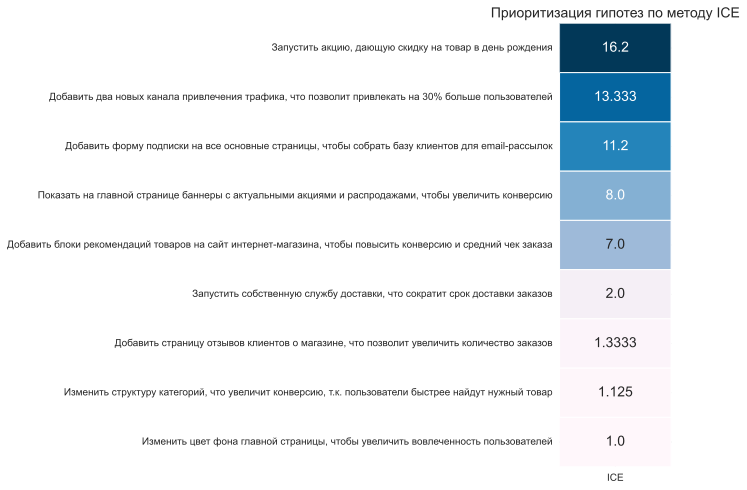

In [26]:
# heatmap ранжирования гипотез по методу ICE
plt.figure(figsize=(2,8))

ICE = hypothesis.pivot_table(index='hypothesis', values='ICE').sort_values(by='ICE', ascending=False)
sns.heatmap(ICE, annot=True, fmt='.5', linewidths= 1, cbar=False, cmap='PuBu', annot_kws={'size':14})
    
plt.title('Приоритизация гипотез по методу ICE', size=14)
plt.ylabel('')

plt.show()

<a id=2.2.></a>
### 2.2. Метод приоритизации гипотез RICE

In [27]:
# применяем фреймворк RICE к датафрейму с гипотезами
hypothesis['RICE'] = (hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence']) / hypothesis['efforts']

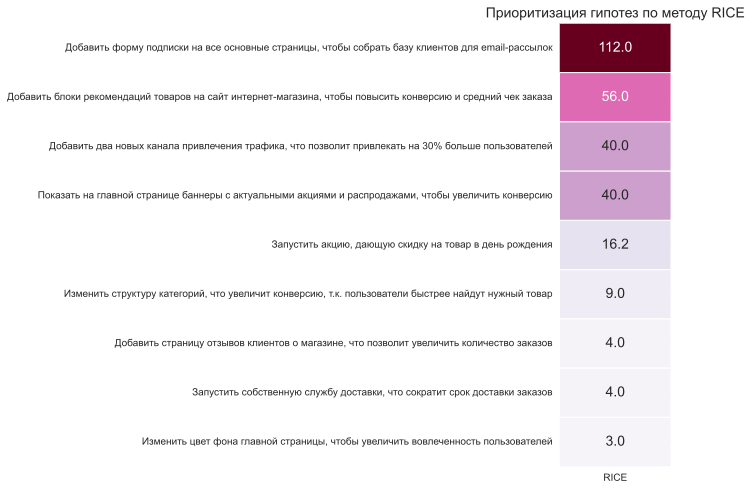

In [28]:
# heatmap ранжирования гипотез по методу RICE
plt.figure(figsize=(2,8))

RICE = hypothesis.pivot_table(index='hypothesis', values='RICE').sort_values(by='RICE', ascending=False)
sns.heatmap(RICE, annot=True, fmt='.5', linewidths= 1, cbar=False, cmap='PuRd', annot_kws={'size':14})
    
plt.title('Приоритизация гипотез по методу RICE', size=14)
plt.ylabel('')

plt.show()

In [29]:
# выводим топ-5 гипотез для обоих скоринговых методов ICE и RICE
hypothesis[['hypothesis', 'RICE', 'ICE']].sort_values(by=['RICE', 'ICE'], ascending=False).round(1).head()

,hypothesis,RICE,ICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.00,11.20
2,"Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа",56.00,7.00
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.00,13.30
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.00,8.00
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20,16.20


**Вывод:** по методу ICE приоритетной гипотезой является предложение №8. "Запустить акцию, дающую скидку на товар в день рождения", её рейтинг является максимальным и равен 16.2. На втором месте по приоритетности в соответствии с методом ICE является гипотеза №0. "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей" с рейтингом 13.3. Третье место занимает гипотеза №7. "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок".

По методу RICE для расчётов учитываются не только критерии влияния, уверенности и трудозатрат на реализацию гипотезы, но также и охват аудитории нововведения. Меняется общая формула вычислений, поэтому в итоге **в метриках метода RICE мы видим более объективную оценку позитивного потенциала нововведения. Здесь на первое место с очень существенным отрывом выходит гипотеза №7 "Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок", её рейтинг по методу RICE составляет 112.0.** Второе место с рейтингом 56.0 занимает гипотеза №2. "Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа". Третье место за гипотезой №0. "Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей" с рейтингом 40.0. 

Таким образом, вне зависимости от выбранной скоринговой системы оценки приоритетности реализации гипотез по методу ICE или RICE, мы видим сформировавшийся топ-5 гипотез, который присутствует в том или ином порядке в обоих финальных расчётах ранжирования. В их числе гипотезы №№ 0, 2, 6, 7, 8.
    
[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5)

<a id=3></a>
## Шаг 3. Анализ A/B-теста

По итогам проведённого A/B-теста нами были получены результаты, описанные в датафреймах `orders.csv` и `visitors.csv`. Приступим к анализу A/B-теста. Чтобы построить графики, нужно собрать кумулятивные данные. Создадим датафрейм `cumulative_data` со столбцами:
* `date` — дата;
* `group` — группа A/B-теста (A или B);
* `orders` — кумулятивное количество заказов на указанную дату в указанной группе;
* `buyers` — кумулятивное количество пользователей, совершивших хотя бы один заказ, на указанную дату в указанной группе;
* `revenue` — кумулятивная выручка на указанную дату в указанной группе (средний чек);
* `visitors` — кумулятивное количество посетителей интернет-магазина на указанную дату в определённой группе.

In [30]:
# создаём массив уникальных пар значений дат и групп теста методом `drop_duplicates()`
dates_groups = orders[['date','group']].drop_duplicates()

Соберём агрегированные кумулятивные по дням данные о заказах в несколько действий.

Получим строки таблицы orders, дата которых меньше или равна дате элемента из datesGroups, а группа теста равна группе из `datesGroups`: `orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]`.

Агрегируем значения. Вычислим максимальную дату. Для группы тоже рассчитаем максимум, и хотя она будет определённой, сделаем это, чтобы столбец `'group'` не пропал из итогового вывода. Найдём число уникальных `ID` заказов и пользователей. Подсчитаем сумму средних чеков:

`.agg({'date' : 'max', 'group' : 'max', 'orderId' : 'nunique', 'userId' : 'nunique', 'revenue' : 'sum'})`. Применим методы к каждой строке датафрейма: `apply(axis=1)` и отсортируем результаты по столбцам `'date'` и `'group'`: 

In [31]:
# сбор агрегированных кумулятивных по дням данных о заказах
orders_aggregated = dates_groups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])
                    ].agg({
    'date' : 'max', 
    'group' : 'max', 
    'transaction_id' : 'nunique', 
    'visitor_id' : 'nunique', 
    'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

# выводим полученный датафрейм для ознакомления 
orders_aggregated.head()

,date,group,transaction_id,visitor_id,revenue
55,2019-08-01,A,23,19,142779
66,2019-08-01,B,17,17,59758
175,2019-08-02,A,42,36,234381
173,2019-08-02,B,40,39,221801
291,2019-08-03,A,66,60,346854


Аналогично получим агрегированные кумулятивные по дням данные о посетителях интернет-магазина: 

In [32]:
# сбор агрегированных кумулятивных по дням данных о посетителях
visitors_aggregated = dates_groups.apply(
    lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group'] == x['group'])
                      ].agg({
        'date' : 'max', 
        'group' : 'max', 
        'visitors' : 'sum'}), axis=1).sort_values(by=['date','group'])

# выводим полученный датафрейм для ознакомления 
visitors_aggregated.head()

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845


Объединим обе таблицы в одну с понятными названиями столбцов:

In [33]:
# создаём массив уникальных пар значений дат и групп теста
dates_groups = orders[['date','group']].drop_duplicates()

# получаем агрегированные кумулятивные по дням данные о заказах 
orders_aggregated = dates_groups.apply(
    lambda x: orders[np.logical_and(
        orders['date'] <= x['date'], orders['group'] == x['group'])
                    ].agg({'date' : 'max', 
                           'group' : 'max', 
                           'transaction_id' : 'nunique', 
                           'visitor_id' : 'nunique', 
                           'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина 
visitors_aggregated = dates_groups.apply(
    lambda x: visitors[np.logical_and(
        visitors['date'] <= x['date'], visitors['group'] == x['group'])
                      ].agg({'date' : 'max', 
                             'group' : 'max', 
                             'visitors' : 'sum'}), axis=1).sort_values(by=['date','group'])

# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cumulative_data = orders_aggregated.merge(visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

In [34]:
# расчёт конверсии
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visitors']

In [35]:
# выводим полученный датафрейм для ознакомления 
cumulative_data.head()

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,23,19,142779,719,0.03
1,2019-08-01,B,17,17,59758,713,0.02
2,2019-08-02,A,42,36,234381,1338,0.03
3,2019-08-02,B,40,39,221801,1294,0.03
4,2019-08-03,A,66,60,346854,1845,0.04


На основе полученного датафрейма `cumulative_data` мы можем приступить к выполнению задач текущего исследовательского раздела проекта.

<a id=3.1.></a>
### 3.1. Кумулятивная выручка по группам: график, выводы, предположения

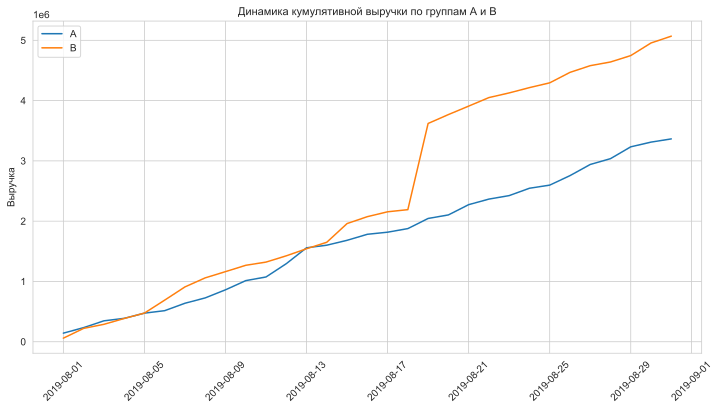

In [36]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12,6))

# строим график выручки группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'], label='A')

# строим график выручки группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'], label='B')

plt.title('Динамика кумулятивной выручки по группам А и В', fontsize = 11)
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.legend()
plt.show();

**Вывод:** кумулятивная выручка групп А и B растут в течение всего тестового периода, это признак положительной динамики. При этом, кумулятивная выручка группы B больше, чем кумулятивная выручка группы A.

На графике выручки группы B на отрезке с 17 августа 2019 года мы видим ощутимый рост. Это может сигнализировать о всплесках числа заказов, либо о появлении очень дорогих заказов в выборке.

<a id=3.2.></a>
### 3.2. Кумулятивный средний чек по группам: график, выводы, предположения

В целях построения графика среднего чека по группам необходимо разделить кумулятивную выручку на кумулятивное число заказов.

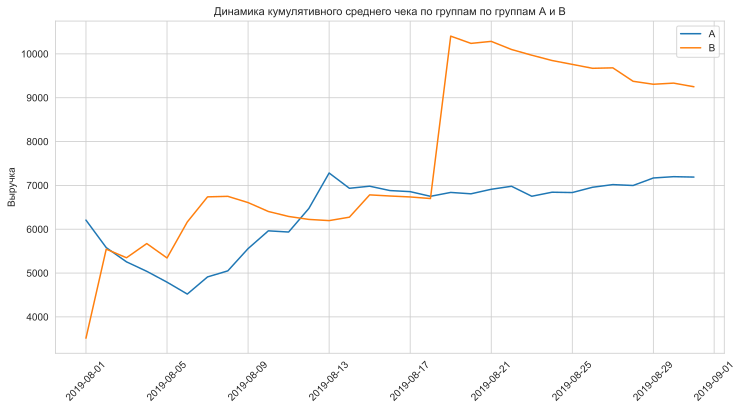

In [37]:
plt.figure(figsize=(12,6))

# строим график кумулятивного среднего чека группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'] / cumulative_revenue_A['orders'], label='A')

# строим график кумулятивного среднего чека группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'] / cumulative_revenue_B['orders'], label='B')

plt.title('Динамика кумулятивного среднего чека по группам по группам А и В', fontsize = 11)
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.legend()
plt.show();

**Вывод:** величина среднего чека по группам колеблется со значительной амплитудой в первой половине периода проведения теста и стабилизируется с 18 августа 2019 года. 

Мы можем предположить, что в группу B в первой половине теста попали крупные заказы и этот всплеск отчётливо виден на графике. Таким образом, для значений группы B требуется больше данных, чтобы прийти к реальному среднему чеку и установиться на его уровне.

<a id=3.3.></a>
### 3.3. Относительное изменение кумулятивного среднего чека группы B к группе A: график, выводы, предположения

В целях построения графика относительного различия для среднего чека добавим горизонтальную ось методом `axhline()` (от англ. horizontal line across the axis, «горизонтальная линия поперек оси»):

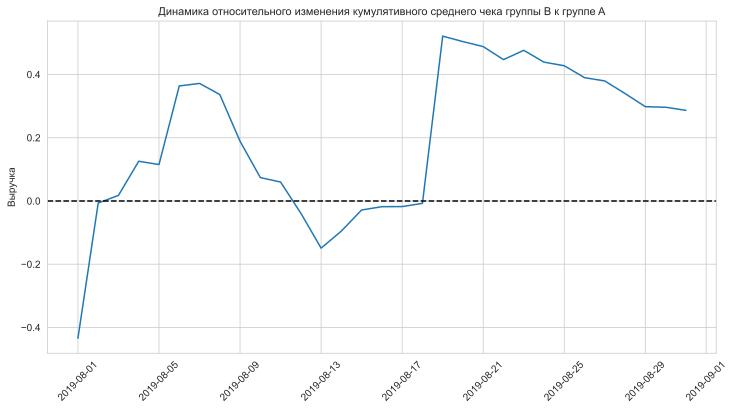

In [38]:
plt.figure(figsize=(12,6))

# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulative_revenue_A.merge(cumulative_revenue_B, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# cтроим отношение средних чеков
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Динамика относительного изменения кумулятивного среднего чека группы B к группе A', fontsize = 11)
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.show();

**Вывод:** как мы уже отметили ранее, на всём периоде теста явно выделяются два периода до и после 18 августа 2019 года. График динамики относительного изменения кумулятивного среднего чека группы B к группе A демонстрирует крутой подъём значений в первой половине периода теста в срок до 7 августа, затем идёт резкое падение и стабилизация на уровне отрицательных значений в период с 18 августа 2019 года. С этой даты вплоть до окончания A/B-теста значение этой метрики группы B идёт в рост и достигает отметки 0.4 - 0.2.

Мы можем предположить, что в первой декаде августа 2019 года были осуществлены крупные покупки, которые отображаются на графике пиковыми значениями.

<a id=3.4.></a>
### 3.4. Кумулятивное среднее количество заказов на посетителя по группам: график, выводы, предположения

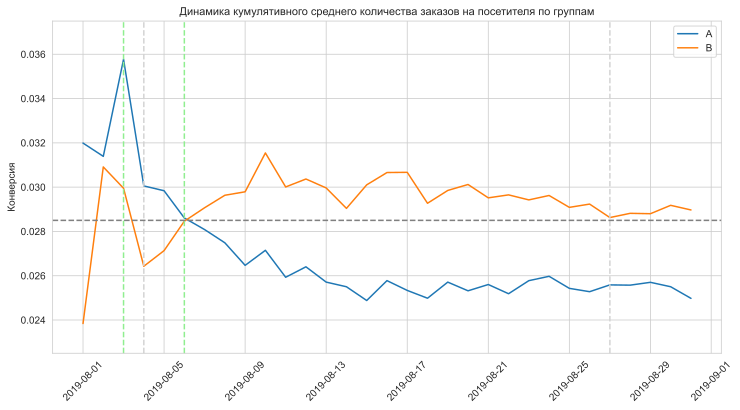

In [39]:
plt.figure(figsize=(12,6))

# считаем кумулятивную конверсию
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visitors']

# отделяем данные по группе A
cumulative_data_A = cumulative_data[cumulative_data['group']=='A']

# отделяем данные по группе B
cumulative_data_B = cumulative_data[cumulative_data['group']=='B']

# строим графики
plt.plot(cumulative_data_A['date'], cumulative_data_A['conversion'], label='A')
plt.plot(cumulative_data_B['date'], cumulative_data_B['conversion'], label='B')

# задаем масштаб оси y
plt.ylim([0.0225, 0.0375])

# линии переломного момента роста конверсии по группам
plt.axvline(x=cumulative_data_A['date'][4], color='lightgreen', linestyle='--') # рубеж 3 августа 2019 года, рост
plt.axvline(x=cumulative_data_A['date'][6], color='lightgray', linestyle='--') # рубеж 4 августа 2019 года, падение
plt.axvline(x=cumulative_data_A['date'][10], color='lightgreen', linestyle='--') # рубеж 6 августа 2019 года, рост
plt.axvline(x=cumulative_data_A['date'][52], color='lightgray', linestyle='--') # рубеж 27 августа 2019 года, падение
plt.axhline(y=0.0285, color='gray', linestyle='--') # линия конверсии в 0.0285

plt.legend()
plt.title('Динамика кумулятивного среднего количества заказов на посетителя по группам', fontsize = 11)
plt.ylabel('Конверсия')
plt.xticks(rotation=45)
plt.show();

**Вывод:** график выглядит симметричным. В период с 1 по 6 августа 2019 года включительно происходило резкое колебание показателей конверсии в обеих группах, при этом в обеих группах рост показателя наблюдался до 3 августа с последующим резким падением. Рост конверсии в группе B возобновился 4 августа 2019 года, и стабильно снижается в группе B. Точка равенства значений конверсии обеих групп теста отмечается 6 августа 2019 года на отметке в 0.0285. После этого рубежа конверсия покупателей в группе B неизменно и стабильно растёт, а в группе А - снижается до отметки 0.025 и стабилизируется на этом уровне вплоть до окончания теста. Одновременно с этим, необходимо отметить, что конверсия покупателей группы B на самом деле далека от идеала и 27 августа 2019 года показатель конверсии в группе B упал до отметки начальной точки роста в 0.0285 с последующим незначительным ростом.

<a id=3.5.></a>
### 3.5. Относительное изменение кумулятивного среднего количества заказов на посетителя группы B к группе A: график, выводы, предположения

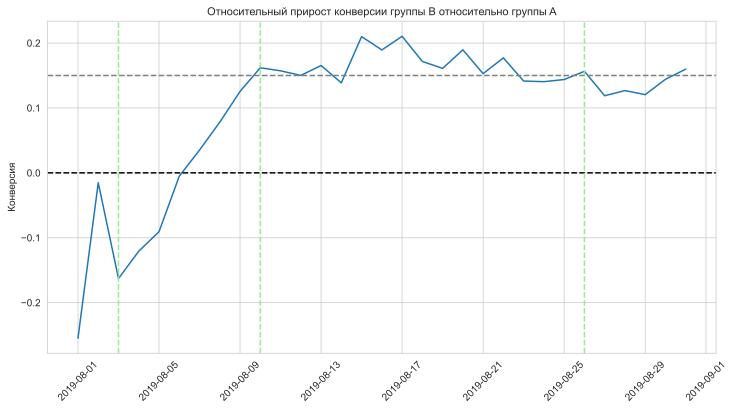

In [40]:
# объединяем таблицы с конверсиями по группам
merged_cumulative_conversions = cumulative_data_A[['date','conversion']].merge(cumulative_data_B[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['_A', '_B'])

# строим график
plt.figure(figsize=(12,6))
plt.plot(merged_cumulative_conversions['date'], merged_cumulative_conversions['conversion_B']/merged_cumulative_conversions['conversion_A']-1)

# нулевой уровень конверсии
plt.axhline(y=0, color='black', linestyle='--')
# конверсия на отметке 0.15
plt.axhline(y=0.15, color='grey', linestyle='--')

# линия переломного момента роста конверсии по группам
plt.axvline(x=cumulative_data_A['date'][4], color='lightgreen', linestyle='--') # рубеж 3 августа 2019 года, рост
plt.axvline(x=cumulative_data_A['date'][18], color='lightgreen', linestyle='--') # рубеж 10 августа 2019 года, рост
plt.axvline(x=cumulative_data_A['date'][50], color='lightgreen', linestyle='--') # рубеж 26 августа 2019 года, падение

plt.title('Относительный прирост конверсии группы B относительно группы A', fontsize = 11)
plt.ylabel('Конверсия')
plt.xticks(rotation=45)
plt.show();

**Вывод:** на раннем этапе проведения A/B-теста группа В явно проигрывала группе А, но затем решительно вырвалась вперед. Конверсия покупателей в группе B стремительно роста в период с 3 по 10 августа 2019 года включительно, далее начинается медленный спад и стабилизация. 26 августа 2019 года конверсия покупателей в группе B вернулась к начальному уровню роста в 0.15, затем наступило кратковременное плато снижения показателя. С 29 августа 2019 года показатель конверсии покупателей группы B снова начал медленно нарастать.

Мы можем предположить, что на визуализацию данных влияют либо крупные заказы, либо большое количество заказов. Необходимо проверить данные на предмет наличия аномально больших значений.

<a id=3.6.></a>
### 3.6. Количество заказов по пользователям

Количество заказов напрямую влияет на конверсию, поскольку находится в числителе этой расчётной формулы. В знаменателе - количество посетителей интернет-магазина за весь период проведения A/B-теста. Частота совершения покупок пользователем в интренет-магазине зависит от продаваемых товаров и услуг: одна-две покупки в месяц в большинстве случаев будут нормой (магазин онлайн-игр, книжный магазин, запчасти или детали для аппаратуры), чаще покупки совершаются в интернет-магазинах, предлагающих товары первой необходимости (продуктовые магазины, аптеки и т.п.). В целях рассмотрения количества заказов по пользователям, необходимо сгруппировать исходные данные датафрейма с заказами `orders.csv`:

In [41]:
# группировка данных по уникальным пользователям
orders_by_users = (orders.groupby('visitor_id', as_index=False).agg({'transaction_id': 'nunique'}))

# присваиваем имена столбцам в получившемся сгруппированном датафрейме
orders_by_users.columns =  ['visitor_id', 'orders']

In [42]:
# первичная описательная статистика по признаку 'orders'
print(orders_by_users['orders'].describe())
print('Среднее значение: ', orders_by_users['orders'].mean())
print('Медианное значение: ', orders_by_users['orders'].median())

count   973.00
mean      1.04
std       0.24
min       1.00
25%       1.00
50%       1.00
75%       1.00
max       3.00
Name: orders, dtype: float64
Среднее значение:  1.0441932168550874
Медианное значение:  1.0


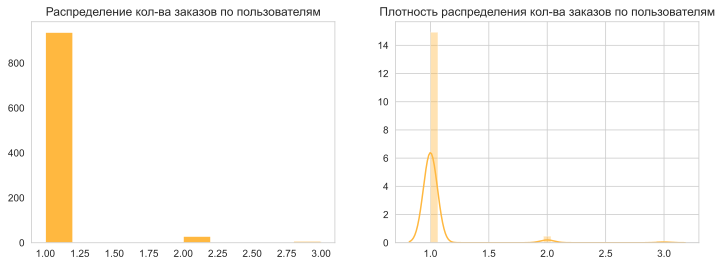

In [43]:
# парные диаграммы для признака 'orders'
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
plt.title('Распределение кол-ва заказов по пользователям')
orders_by_users['orders'].hist(figsize=(12,4), grid=False, color='#FFB840').set(ylabel = '', xlabel = '')

plt.subplot(1,2,2)
plt.title('Плотность распределения кол-ва заказов по пользователям')
sns.distplot(orders_by_users['orders'], color = '#FFB840').set(ylabel = '', xlabel = '')

plt.show()

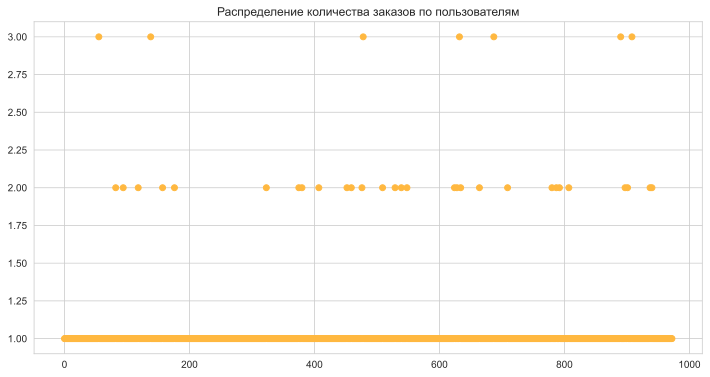

In [44]:
# точечная диаграмма для признака 'orders'
x_values = pd.Series(range(0,len(orders_by_users)))

plt.scatter(x_values, orders_by_users['orders'], color='#FFB840')
plt.title('Распределение количества заказов по пользователям')
plt.show();

**Вывод:** полученные результаты описательной статистики и визуализация графиков типа `hist`, `distplot` и `scatter` позволяют нам сделать однозначный вывод о численном превосходстве посетителей интернет-магазина, которые за период проведения A/B-теста совершили только один заказ: таких посетителей 935 из 971, что составляет 96.29%. Количество посетителей, совершивших 2 заказа в период тестирования - всего 29 человек (или 2.98%), 3 заказа - 7 человек (или 0.72%). 

<a id=3.7.></a>
### 3.7. Граница для определения аномалий по количеству заказов на пользователя

In [45]:
# перцентили количества заказов на одного пользователя
np.percentile(orders_by_users['orders'], [95, 99])

array([1., 2.])

**Вывод:** только 1% пользователей интернет-магазина совершил более 2 покупок за период проведения A/B-теста. Примем за верхнюю границу 2 заказа на одного пользователя.

<a id=3.8.></a>
### 3.8. Стоимости заказов пользователей

In [46]:
# первичная описательная статистика по признаку 'revenue'
print(orders['revenue'].describe())
print('Среднее значение: ', orders['revenue'].mean())
print('Медианное значение: ', orders['revenue'].median())

count      1016.00
mean       8300.81
std       42121.99
min          50.00
25%        1190.00
50%        2955.00
75%        8134.25
max     1294500.00
Name: revenue, dtype: float64
Среднее значение:  8300.814960629921
Медианное значение:  2955.0


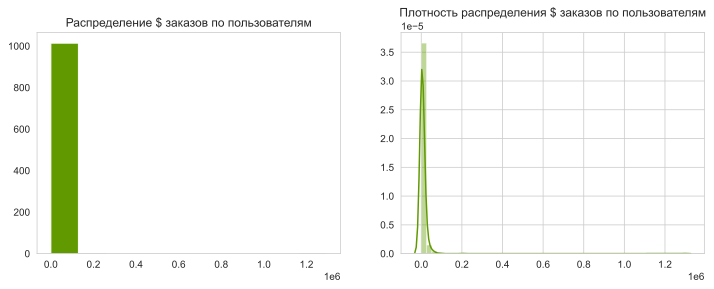

In [47]:
# парные диаграммы для признака 'revenue'
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
plt.title('Распределение $ заказов по пользователям')
orders['revenue'].hist(figsize=(12,4), grid=False, color='#619A00').set(ylabel = '', xlabel = '')

plt.subplot(1,2,2)
plt.title('Плотность распределения $ заказов по пользователям')
sns.distplot(orders['revenue'], color = '#619A00').set(ylabel = '', xlabel = '')

plt.show()

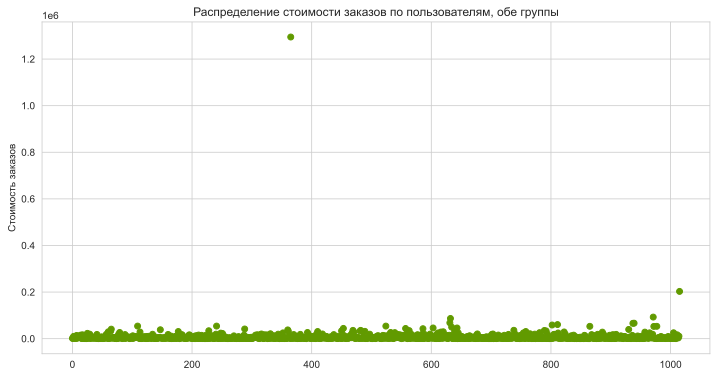

In [48]:
# точечная диаграмма для признака 'orders'
x_values = pd.Series(range(0,len(orders['revenue'])))

plt.scatter(x_values, orders['revenue'], color='#619A00')
plt.title('Распределение стоимости заказов по пользователям, обе группы')
plt.ylabel('Стоимость заказов')
plt.show();

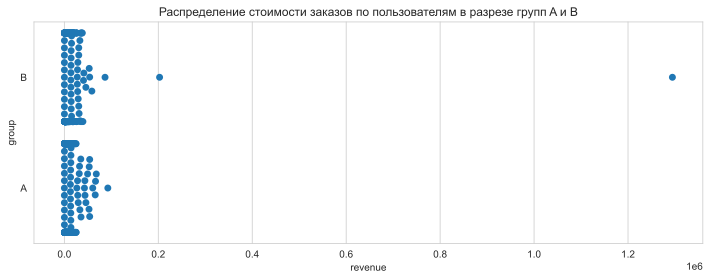

In [49]:
# визуализация зависимости стоимости заказов от группы теста
plt.figure(figsize=(12,4))
sns.swarmplot(data = orders, y='group', x='revenue', size=7)
plt.title('Распределение стоимости заказов по пользователям в разрезе групп A и B')
plt.show();

**Вывод:** существенная разница между средними и медианными значениями свидетельствует о неоднородности данных и присутствии большого количества аномальных значений по признаку 'revenue' в обеих группах, этот тезис подтверждается графиками визуализации признака как на обобщённых данных, так и в разрезе по группам A и B. Абсолютное большинство (95% пользователей) совершили покупки на сумму до 26 550 денежных единиц. В условной средней стоимостной категории от 26 550 до 53 904 мы можем насчитать 39 заказов, а свыше этой суммы - всего лишь 9 заказов.

<a id=3.9.></a>
### 3.9. Граница для определения аномалий по стоимости заказов

In [50]:
# перцентили стоимости заказов на одного пользователя
np.percentile(orders['revenue'], [95, 99])

array([26785., 53904.])

На этапе предвартельной обработки данных нами была подготовлена агрегированная таблица с описательными статистиками признака 'revenue' в разрезе групп A и B на исходном датафрейме `orders.csv`. Дополним эту таблицу обобщённым значением `revenue` по обоим группам и заполним графы актуальными значениями.

*Таблица 4. Агрегированные статистические значения признака 'revenue'*

|Наименование группы|min|mean|median|Q3  |Q99  |Q100 |Порог аномальных значений|Количество значений выше Q99|Количество значений выше порога аномальных значений|
|:------------------|:--|:---|:-----|:---|:----|:----|:----|:----|:----|
|Общие значения     |50 |6840|2955  |8090|53904|92550|18440|10|92|
|Группа А           |50 |7189|3090  |8438|56064|92550|19349|5|35|
|Группа B           |50 |6541|2865  |7817|41130|86620|17650|5|57|

Граница для определения аномальных пользователей может быть установлена на уровне 95-ого, 99-ого перцентиля или расчитана по формуле:

$$\text{Q3} + 1,5 \times \text{IQR},$$ где $$ \text{IQR} = \text{Q3} - \text{Q1}$$

<br>*Q1* — первый квартиль; 
<br>*Q3* — третий квартиль. 

Из полученных расчётов следует, что при установлении границ для отсечения аномальных данных, полученных по формуле Q3 + 1.5 IQR, потери данных будут существенными и составят 92 строки или 9.02%. При установлении границ аномальных данных по 99-перцентилю потери в данных будут минимальными и составят 10 строк или 0.98%.
<br>**Вывод:** устанавливаем границу стоимости заказа на уровне отметки 99% перцентиля, равного 53 904 денежных единиц.

<a id=3.10.></a>
### 3.10. Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным

На предыдущих этапах исследования мы визуально оценили результаты A/B-теста и выяснили, что в данных предположительно имеются выбросы. Нами были визуализировали выбросы и установлены числовые границы для их определения.

Рассчитаем статистическую значимость различий в среднем числе заказов на пользователя и среднем чеке между группами по «сырым» данным — без удаления аномальных пользователей.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : конверсия в группе A} = \text{конверсия в группе B}
   \\
   \text{H}_1 \text{ : конверсия в группе A} \neq \text{конверсия в группе B}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

Для дальнейшей работы необходимо подготовить соответствующий датафрейм. Практика показывает, что данные о продажах и средних чеках редко бывают нормально распределены и это весьма распространённый пример переменных, подверженных выбросам. Следовательно, для проверки гипотез нами будет использован непараметрический `тест Уилкоксона-Манна-Уитни`. В качестве порогового значения мы установим стандартный уровень статистической значимости, равный `0.05`.

Создадим датафрейм `data`, в котором в разрезе групп соберём данные о дате, количестве заказов в выбранную дату, суммарном количестве заказов до выбранной даты включительно, суммарнаой выручке до выбранной даты включительно, количестве пользователей в выбранную дату в соответствующей группе и количестве пользователей до выбранной даты включительно в соответствующей группе.

In [51]:
# создаём массив данных `data`
visitors_daily_A = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitors_daily_A.columns = ['date', 'visitors_per_date_A']

visitors_cummulative_A = visitors_daily_A.apply(
    lambda x: visitors_daily_A[visitors_daily_A['date'] <= x['date']].agg(
        {'date': 'max', 'visitors_per_date_A': 'sum'}), axis=1,)
visitors_cummulative_A.columns = ['date', 'visitors_cummulative_A']

visitors_daily_B = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitors_daily_B.columns = ['date', 'visitors_per_date_B']

visitors_cummulative_B = visitors_daily_B.apply(
    lambda x: visitors_daily_B[visitors_daily_B['date'] <= x['date']].agg(
        {'date': 'max', 'visitors_per_date_B': 'sum'}), axis=1,)
visitors_cummulative_B.columns = ['date', 'visitors_cummulative_B']

orders_daily_A = (
    orders[orders['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'}))
orders_daily_A.columns = ['date', 'orders_daily_A', 'revenue_per_date_A']

orders_cummulative_A = orders_daily_A.apply(
    lambda x: orders_daily_A[orders_daily_A['date'] <= x['date']].agg(
        {'date': 'max', 'orders_daily_A': 'sum', 'revenue_per_date_A': 'sum'}), axis=1,).sort_values(by=['date'])

orders_cummulative_A.columns = ['date','orders_cummulative_A','revenue_cummulative_A']

orders_daily_B = (
    orders[orders['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'}))
orders_daily_B.columns = ['date', 'orders_daily_B', 'revenue_per_date_B']

orders_cummulative_B = orders_daily_B.apply(
    lambda x: orders_daily_B[orders_daily_B['date'] <= x['date']].agg(
        {'date': 'max', 'orders_daily_B': 'sum', 'revenue_per_date_B': 'sum'}), axis=1,).sort_values(by=['date'])

orders_cummulative_B.columns = ['date','orders_cummulative_B','revenue_cummulative_B']

data = (orders_daily_A.merge(
        orders_daily_B, left_on='date', right_on='date', how='left')
    .merge(orders_cummulative_A, left_on='date', right_on='date', how='left')
    .merge(orders_cummulative_B, left_on='date', right_on='date', how='left')
    .merge(visitors_daily_A, left_on='date', right_on='date', how='left')
    .merge(visitors_daily_B, left_on='date', right_on='date', how='left')
    .merge(visitors_cummulative_A, left_on='date', right_on='date', how='left')
    .merge(visitors_cummulative_B, left_on='date', right_on='date', how='left'))

In [52]:
# выводим датафрейм для ознакомления
display(data.shape)
data.head()

(31, 13)

,date,orders_daily_A,revenue_per_date_A,orders_daily_B,revenue_per_date_B,orders_cummulative_A,revenue_cummulative_A,orders_cummulative_B,revenue_cummulative_B,visitors_per_date_A,visitors_per_date_B,visitors_cummulative_A,visitors_cummulative_B
0,2019-08-01,23,142779,17,59758,23,142779,17,59758,719,713,719,713
1,2019-08-02,19,91602,23,162043,42,234381,40,221801,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,66,346854,54,288850,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,77,388030,68,385740,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,99,474413,89,475648,756,707,3318,3280


Итак, в полученном датафрейме `data` содержатся данные в 31 строке в разрезе следующих 13 признаков:
    
|№ п/п|Наименование признака   |Краткое описание признака|
|:----|:-----------------------|:------------------------|
|1.   |`date`                  |календарная дата|
|2.   |`orders_daily_A`        |количество заказов в выбранную дату в группе A|
|3.   |`orders_daily_B`        |количество заказов в выбранную дату в группе B|
|4.   |`revenue_per_date_A`    |суммарная выручка в выбранную дату в группе A|
|5.   |`revenue_per_date_B`    |суммарная выручка в выбранную дату в группе B|
|6.   |`orders_cummulative_A`  |суммарное количество заказов до выбранной даты включительно в группе A|
|7.   |`orders_cummulative_B`  |суммарное количество заказов до выбранной даты включительно в группе B|
|8.   |`revenue_cummulative_A` |суммарная выручка до выбранной даты включительно в группе A|
|9.   |`revenue_cummulative_B` |суммарная выручка до выбранной даты включительно в группе B|
|10.  |`visitors_per_date_A`   |количество пользователей в выбранную дату в группе A|
|11.  |`visitors_per_date_B`   |количество пользователей в выбранную дату в группе B|
|12.  |`visitors_cummulative_A`|количество пользователей до выбранной даты включительно в группе A|
|13.  |`visitors_cummulative_B`|количество пользователей до выбранной даты включительно в группе B|

Нам предстоит создать переменные `orders_by_users_A` и `orders_by_users_B` со столбцами `['user_id', 'orders']` и поместить в них число заказов для пользователей, которые совершили хотя бы 1 покупку в интернет-магазине. 

In [53]:
# создаём переменные с данными о количестве совершённых заказов пользователей в разрезе групп
orders_by_users_A = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique}))
orders_by_users_A.columns = ['visitor_id', 'orders']

orders_by_users_B = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique}))
orders_by_users_B.columns = ['visitor_id', 'orders']

Объявляем переменные `sample_A` и `sample_B`, в которых пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни.

Переменная `sample_A` должна состоять из двух частей:
1. Список с количеством заказов для каждого из пользователей: `orders_by_users_A['orders']`.
2. Нули для пользователей, которые ничего не заказывали. Их количество равно разнице между суммой посетителей и количеством записей о заказах: `data['visitors_per_date_A'].sum() - len(orders_by_users_A['orders'])`.

Для второй части переменной `sample_A` создадим объект `pd.Series` нужной длины, при этом список индексов мы создаём функцией `np.arange()`. Она создаёт массив индексов в формате `np.array`, который требуется в `pd.Series`.

In [54]:
# создаём массив данных о нулевом количестве заказов
pd.Series(0, index=np.arange(data['visitors_per_date_A'].sum() - len(orders_by_users_A['orders'])), name='orders')

0        0
1        0
2        0
3        0
4        0
        ..
18286    0
18287    0
18288    0
18289    0
18290    0
Name: orders, Length: 18291, dtype: int64

С помощью функции конкатенации объединим списки количества заказов там, где они есть и нули для пользователей, который ничего не заказали:

In [55]:
# создаём переменные с данными о соответствии количества заказов в разрезе групп
sample_A = pd.concat([orders_by_users_A['orders'],
                      pd.Series(0, 
                                index=np.arange(data['visitors_per_date_A'].sum() - 
                                                len(orders_by_users_A['orders'])), name='orders')], axis=0)

sample_B = pd.concat([orders_by_users_B['orders'],
                      pd.Series(0, 
                                index=np.arange(data['visitors_per_date_B'].sum() - 
                                                len(orders_by_users_B['orders'])), name='orders')], axis=0)

Поскольку в соответствии с проектным заданием нам предстоит провести несколько раз аналогичные расчёты, полагаем уместным создать функцию, выводящую:
* значение p-value;
* получилось либо не получилось отвергуть нулевую гипотезу;
* относительный прирост.

Для этого, применим критерий Манна-Уитни и выведем значение p-value, округлив его до трёх знаков после запятой.

В `sample_A` была сохранена выборка, где каждый элемент — число заказов определённого пользователя, в том числе ноль. Значит, число элементов `sample_A` — это количество пользователей, сумма всех элементов — количество заказов. Чтобы получить среднее число заказов на пользователя, необходимо поделить сумму заказов на число пользователей — так мы можем найти среднее в выборке `sample_A` методом `mean()`. Аналогично найдём среднее группы B: `sample_B.mean()`.

Далее, выведем относительный прирост среднего числа заказов группы B: `среднее число заказов группы B / среднее число заказов группы A - 1`. Также округлим полученное значение до трёх знаков после запятой.

In [56]:
# создаём функцию для проверки гипотезы
def stat_diff(data_A, data_B):
    alpha = 0.05
    p_value = stats.mannwhitneyu(data_A, data_B, alternative='two-sided')[1] # добавлен параметр alternative='two-sided'
    print('p-value: {0:.3f}'.format(p_value))

    if (p_value < alpha):
        print('Отвергаем нулевую гипотезу: разница в средних значениях групп статистически значима.')
    else:
        print('Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными.')
    
    print('Относительный прирост группы В к группе А: {0:.3%}'.format(data_B.mean() / data_A.mean()-1))

In [57]:
# применяем функцию для проверки гипотезы
stat_diff(sample_A, sample_B)

p-value: 0.011
Отвергаем нулевую гипотезу: разница в средних значениях групп статистически значима.
Относительный прирост группы В к группе А: 15.980%


**Вывод:** на основании расчётов по «сырым» данным мы получили значение p-value, равное 0.013, что существенно меньше установленного порогового значения $ \alpha = 0.05$. Следовательно, нулевую гипотезу о равенстве средних значений конверсии по группам A и B мы можем отвергнуть. Расчитанный относительный прирост среднего числа заказов группы B равен 15.556%.

<a id=3.11.></a>
### 3.11. Статистическая значимость различий в среднем чеке заказа между группами по «сырым» данным

Рассчитаем статистическую значимость различий в среднем чеке между группами по «сырым» данным — без удаления аномальных пользователей.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : средний чек в группе A} = \text{средний чек в группе B}
   \\
   \text{H}_1 \text{ : средний чек в группе A} \neq \text{средний чек в группе B}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [58]:
# передаём в переменные данные о размере оплаты заказов в разрезе групп
pay_A = orders[orders['group']=='A']['revenue']
pay_B = orders[orders['group']=='B']['revenue']

In [59]:
# применяем функцию для проверки гипотезы
stat_diff(pay_A, pay_B)

p-value: 0.829
Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными.
Относительный прирост группы В к группе А: 28.660%


**Вывод:** в результате вычислений нами получено значениe p-value 0.752, значительно превышающее установленный порог статистической значимости 0.05. Следовательно, мы не можем отвергуть нулевую гипотезу о наличии разницы между значениями среднего чека в группе A и B. Обратимся к цифрам: средний чек в группе A составляет порядка 7 189 денежных единиц, а в группе B этот показатель равен 6 541. Разница между этиим значениями составляет 647 денежных единиц или 9% с перевесом в сторону группы A.

<a id=3.12.></a>
### 3.12. Статистическая значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

Ранее нами были установлены границы аномальных значений для количества заказов и для стоимости заказов. Убираем из анализа по 1% пользователей, которые по своим значениям активности на сайте интренет-магазина превысил границы аномальных значений : совершил больше 2 покупок или стоимость заказа пользователя составила более 53 904 денежных единиц. Сделаем срезы данных и передадим пользователей с числом заказов больше 2 в переменную `users_with_many_orders` и пользователей, совершивших заказы дороже 52 900 в переменную `users_with_expensive_orders`. Объединим эти данные в таблице `abnormal_users`, а затем узнаем, сколько всего аномальных пользователей методом `shape()`.

In [60]:
# передаём в переменные пороговые границы аномальных значений по количеству заказов и их стоимости 
many_orders = np.percentile(orders_by_users['orders'], 99)
expensive_orders = np.percentile(orders['revenue'], 99)

In [61]:
# собираем промежуточные данные для таблицы 'abnormal_users'
users_with_many_orders = pd.concat(
    [orders_by_users_A[orders_by_users_A['orders'] > many_orders]['visitor_id'],
     orders_by_users_B[orders_by_users_B['orders'] > many_orders]['visitor_id'],],axis=0)

users_with_expensive_orders = orders[orders['revenue'] > expensive_orders]['visitor_id']

# собираем таблицу 'abnormal_users'
abnormal_users = (pd.concat(
    [users_with_many_orders, users_with_expensive_orders], axis=0)
    .drop_duplicates().sort_values())

In [62]:
# выводим полученную таблицу для ознакомления
abnormal_users.head()

1099    148427295
33      249864742
58      611059232
949     887908475
744     888512513
Name: visitor_id, dtype: int64

In [63]:
# выводим число строк в таблице 'abnormal_users'
abnormal_users.shape[0]

16

Всего 16 аномальных пользователей. Узнаем, как их действия повлияли на результаты теста. Посчитаем статистическую значимость различий в среднем количестве заказов между группами теста по «очищенным» данным. Сначала подготовим выборки количества заказов по пользователям по группам теста:

In [64]:
# с помощью метода логического исключения фильтруем данные в переменных 'sample_A' и 'sample_B'
sample_A_filtered = pd.concat(
    [orders_by_users_A[np.logical_not(orders_by_users_A['visitor_id'].isin(abnormal_users))]['orders'],
        pd.Series(0, index=np.arange(data['visitors_per_date_A'].sum() - len(orders_by_users_A['orders'])), 
                  name='orders',),], axis=0)

sample_B_filtered = pd.concat(
    [orders_by_users_B[np.logical_not(orders_by_users_B['visitor_id'].isin(abnormal_users))]['orders'],
        pd.Series(0, index=np.arange(data['visitors_per_date_B'].sum() - len(orders_by_users_B['orders'])), 
                  name='orders',),], axis=0)

Рассчитаем статистическую значимость различий в среднем числе заказов на пользователя и среднем чеке между группами по «очищенным» данным — с удалением аномальных пользователей.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : конверсия в группе A} = \text{конверсия в группе B}
   \\
   \text{H}_1 \text{ : конверсия в группе A} \neq \text{конверсия в группе B}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [65]:
# применим статистический критерий Манна-Уитни к полученным выборкам
stat_diff(sample_A_filtered, sample_B_filtered)

p-value: 0.007
Отвергаем нулевую гипотезу: разница в средних значениях групп статистически значима.
Относительный прирост группы В к группе А: 18.921%


**Вывод:** на «сырых» данных мы отвергли нулевую гипотезу о равенстве конверсий в группе A и B. На «очищенных» данных нулевая гипотеза также была отвергнута, конверсии в группах теста разные. Расчитанный относительный прирост среднего числа заказов группы B на «сырых» данных равен 15.5%, а на «очищенных» он ощутимо выше и составляет 19.2%.

<a id=3.13.></a>
### 3.13. Статистическая значимость различий в среднем чеке заказа между группами по «очищенным» данным

Рассчитаем статистическую значимость различий в среднем чеке между группами по «очищенным» данным — с удалением аномальных пользователей.

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : средний чек в группе A} = \text{средний чек в группе B}
   \\
   \text{H}_1 \text{ : средний чек в группе A} \neq \text{средний чек в группе B}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.05$

In [66]:
# передаём в переменные данные о размере оплаты заказов в разрезе групп
pay_A_filtered = orders[(orders['group']=='A') & np.logical_not(orders['visitor_id'].isin(abnormal_users))]['revenue']
pay_B_filtered = orders[(orders['group']=='B') & np.logical_not(orders['visitor_id'].isin(abnormal_users))]['revenue']

In [67]:
# применяем функцию для проверки гипотезы
stat_diff(pay_A_filtered, pay_B_filtered)

p-value: 0.788
Не получилось отвергнуть нулевую гипотезу, нет оснований считать группы разными.
Относительный прирост группы В к группе А: -3.234%


**Вывод:** в результате вычислений на «сырых» данных нами получено значениe p-value 0.752, значение p-value, полученное по «очищенным» данным, составляет 0.842. Оба результата значительно превышают установленный порог статистической значимости 0.05. Для обоих случаев мы не можем отвергуть нулевую гипотезу о наличии разницы между значениями среднего чека в группе A и B.

Соотношение среднего чека на «сырых» данных составляет порядка 7 189 денежных единиц в группе А к 6 541 денежной единице в группе B. Разница между этиим значениями составляет 647 денежных единиц с перевесом в сторону группы A. На «очищенных» данных этот показатель выровнялся. Так, средний чек на «очищенных» данных в группе А равен 6 274 денежных единиц, в группе B 6 188 денежных единиц. Разница между значениями минимальная и оставляет 85 денежных единиц с перевесом в сторону группы А.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5)

<a id=4></a>
## Шаг 4. Принятое решение по результатам теста и его аргументация

Создадим вспомогательные данные для визуального подкрепления полученных ранее результатов и обоснования принятого решения. 

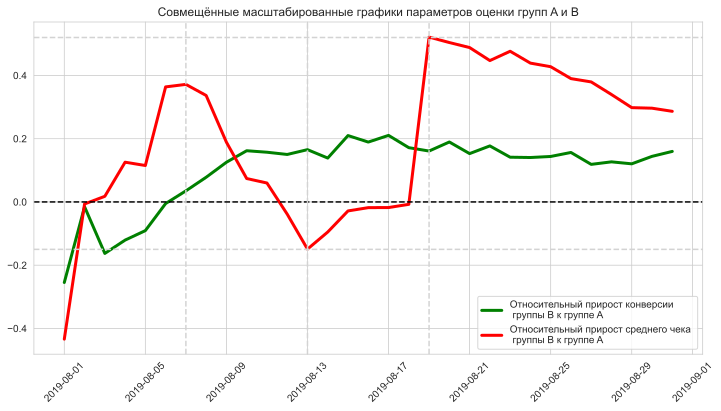

In [68]:
# график различия среднего количества заказов в разрезе групп
plt.figure(figsize=(12,6))

x1 = merged_cumulative_conversions['date']
y1 = merged_cumulative_conversions['conversion_B']/merged_cumulative_conversions['conversion_A']-1
x2 = mergedCumulativeRevenue['date']
y2 = (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1

plt.plot(x1, y1, 'g-', linewidth=3, label='Относительный прирост конверсии \n группы B к группе A')
plt.plot(x2, y2, 'r-', linewidth=3, label='Относительный прирост среднего чека \n группы B к группе A')

plt.axhline(y=0, color='black', linestyle='--') # нулевой уровень конверсии
plt.axvline(x=mergedCumulativeRevenue['date'][6], color='lightgray', linestyle='--') # рубеж 7 августа 2019 года, падение чека
plt.axvline(x=mergedCumulativeRevenue['date'][12], color='lightgray', linestyle='--') # рубеж 13 августа 2019 года, стабилизация чека
plt.axvline(x=mergedCumulativeRevenue['date'][18], color='lightgray', linestyle='--') # рубеж 19 августа 2019 года, пик роста чека
plt.axhline(y=-0.15, color='lightgray', linestyle='--')
plt.axhline(y=0.52, color='lightgray', linestyle='--')

plt.title('Совмещённые масштабированные графики параметров оценки групп A и B')
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.show();

В агрегированном виде полученные результаты проведения A/B-теста представлены ниже:

*Таблица 5. Результаты статистических тестов в разрезе групп*

|                                                                                         |по «сырым» данным|по «очищенным» данным|
|:----------------------------------------------------------------------------------------|:----------------|:--------------------|
|p-уровень значимости различий по среднему количеству заказов на посетителя между группами|0.011            |0.007                |
|относительный прирост группы В к группе А по среднему количеству заказов на посетителя   |15.556%          |18.921%              |
|p-уровень значимости различий в среднем чеке заказа между группами                       |0.829            |0.788                |
|относительный прирост группы В к группе А по величине среднего чека заказа               |28.660%          |-3.234%              |


Установленные факты:
* Есть статистически значимые различия по среднему количеству заказов между группами и по «сырым», и по «очищенным» от аномалий данным;
* Нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по «очищенным» от аномалий данным;
* График различия среднего количества заказов между группами сообщает, что результаты группы B лучше группы A и сохраняется позитивная стабильность с незначительным ростом после 25 августа 2019 года;
* График различия среднего чека говорит о том, что результаты группы B c 19 августа 2019 года стали снижаться.

По условию практического задания, нам были предложены следующие врианты решения по результатам теста:
<br>1. Остановить тест, зафиксировать победу одной из групп.
<br>2. Остановить тест, зафиксировать отсутствие различий между группами.
<br>3. Продолжить тест.

Исходя из выявленных фактов, полагаем необходимым **остановить тест, зафиксировать победу группы B.** При имеющихся данных:
1. Кумулятивная выручка по группе B выше, чем по группе A.
2. Показатель конверсии пользователей в группе B существенно выше аналогичного показателя в группе A на 15.5% по «сырым» данным и на 18.9% по «очищенным» данным.
3. Средний чек пользователей в группе B находился в стадии активного роста очень короткий период c 17 по 19 августа, за которым последовало падение и стабилизация с очень медленной тенденцией роста до отметки -3% от среднего чека группы А.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5)

<a id=5></a>
## Шаг 5. Вывод

</span><div style="text-align: justify"> На заре развития всемирной сети Интернет едва ли кто-то мог предположить, что online-покупки станут настолько популярным и общепринятым способом торговли. Даже когда торговля уже сделала решительный шаг в цифровую реальность, многие пользователи с недоверием и опаской относились к идее удалённого шоппинга. С лавинообразным развитием цифровых технологий, популярность виртуальных торговых площадок стала неоспоримым фактом, а сами online-покупки - неотъемлемой частью жизни многих людей. К примеру, в России доля интернет-торговли в общем объёме розничных продаж по итогам 2021 года составила 9,2%, а доля россиян, заказывающих товары или услуги по Сети, за период с 2013 по 2021 гг. выросла с 15% до 47%. Аудитория российской интернет-торговли в 2021 году составила 70 млн человек, а количество заказов с учётом возвратов подобралось к отметке 2,6 млрд. Такие данные приводятся в <a href='https://issek.hse.ru/news/768845773.html'>исследовании Института статистических исследований и экономики знаний НИУ ВШЭ</a>.</div><br>
<div style="text-align: justify">Высокая популярность и повсеместное  признание  пользователей  являются следствием характерных  черт  организационных  принципов работы интернет-магазинов:
<ul>
<li>большой ассортимент без сезонных ограничений;</li>
<li>выгодные цены по сравнению с офлайн рынком, продукция в онлайн стоит дешевле (владелец виртуальной точки не платит за аренду торгового зала и коммунальных услуг, не нанимает десяток продавцов-консультантов);</li>
<li>быстрая навигация в ассортименте (фильтрация потребительских характеристик помогает быстро отобрать необходимые по качеству и количеству товары);</li>
<li>круглосуточная доступность (интернет-магазины открыты в режиме 24/7, работают в выходные и праздники);</li>
<li>быстрое информирование пользователя об новинках, акциях, скидках.</li>
</ul><br>
<div style="text-align: justify">Рынок следует за потребителем: традиционные офлайн розничные магазины открывают интернет-магазины, организовывают доставку на дом, общаются с покупателями вне точек продаж через социальные сети и мессенджеры. Одновременно с этим, безусловно, при всех достоинствах и сильных сторонах, интернет-торговля обладает и слабыми сторонами:
<ul>
<li>нестабильной работы сайта;</li>
<li>сложной организации логистики;</li>
<li>перенасыщенности рынка;</li>
<li>высокого риска мошенничества;</li>
<li>времени на создание и запуск сайта интернет-магазина.</li>
</ul>
<div style="text-align: justify">Данное проектное исследование посвящено анализу деятельности уже существующего крупного интернет-магазина. В роли аналитика данных, нам предстояло приоритизировать гипотезы для увеличения выручки, разработанный отделом маркетинга, а также запустить А/В тест и проанализировать полученные результаты. В соответствии с этими задачами, в работу поступило 3 датафрейма, в их числе датафрейм `hypothesis.csv` для первой части исследования, посвящённой приоритизации гипотез, а также датафреймы `orders.csv` и `visitors.csv` непосредственно для второй части исследования с информацией о заказах и посещениях интернет-магазина за период с 1 по 31 августа 2019 года включительно для анализ результатов A/B-теста.</div>

<p><span style="font-weight:700;font-size:20px"> ШАГ 1.</span>
<div style="text-align: justify">На этом этапе нами был импортирован ряд специализированных библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов. Осуществлена загрузка исходных файлов с данными методом `read_csv`. На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()`, а также цепочки методов `isna().sum()` и `duplicated().sum()` мы получили первичную информацию для статистического анализа.<br><br>
Выполнена предварительная обработка данных: преобразование типов данных о дате заказа и дате посещения интернет-магазина. Пропусков в данных нет, полных дубликатов нет. <font color='#880045'> Установлено 2 критических отклонения от дизайна A/B-тестирования: в датафрейме `orders.csv` выявлено одновременное присутствие 58 пользователей  в обеих группах тестирования. Установлено некорректное деление трафика теста, выраженное в численном превосходстве пользователей в группе B по отношению к группе A в размере 45.73% к 54.27%, разница составляет 8.5% вместо рекомендованного 1%.</font>  В датафрейме `orders.csv` после удаления пересечения данных по пользователям, присутствующим в обеих группах тестирования одновременно (181 строка) и аномальных значений признака 'revenue' по группе B (2 строки) осталось 1 014 строк, потери данных составили 15.3%.</div>
    
<p><span style="font-weight:700;font-size:20px"> ШАГ 2.</span>
<div style="text-align: justify">Приоритизация гипотез по увеличению выручки интернет-магазина была проведена по методам ICE и RICE. Так, по методу ICE приоритетной гипотезой является предложение №8. «Запустить акцию, дающую скидку на товар в день рождения», её рейтинг является максимальным и равен 16.2. На втором месте по приоритетности в соответствии с методом ICE является гипотеза №0. «Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей» с рейтингом 13.3. Третье место занимает гипотеза №7. «Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок».<br><br>
По методу RICE для расчётов учитываются не только критерии влияния, уверенности и трудозатрат на реализацию гипотезы, но также и охват аудитории нововведения. Меняется общая формула вычислений, поэтому в итоге <font color='#880045'>в метриках метода RICE мы видим более объективную оценку позитивного потенциала нововведения. Здесь на первое место с очень существенным отрывом выходит гипотеза №7 «Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок»,</font> её рейтинг по методу RICE составляет 112.0. Второе место с рейтингом 56.0 занимает гипотеза №2. «Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа». Третье место за гипотезой №0. «Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей» с рейтингом 40.0.</div></p></p></p></p></p></p>

<i>Таблица. Ранжирование гипотез по методу ICE и методу RICE</i>

|№ п/п|Описание гипотезы                                                                |Скоринг по RICE|Скоринг по ICE|
|-|------------------------------------------------------------------------------------------------------------|------|---|
|<font color='#880045'>7|<font color='#880045'>Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок            |<font color='#880045'>112.00|<font color='#880045'>11.20|
|2|Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа|56.00 |7.00|
|0|Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей          |40.00 |13.30|
|6|Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию        |40.00 |8.00|
|8|Запустить акцию, дающую скидку на товар в день рождения                                                     |16.20 |16.20|

<br><div style="text-align: justify">Таким образом, вне зависимости от выбранной скоринговой системы оценки приоритетности реализации гипотез по методу ICE или RICE, мы видим сформировавшийся топ-5 гипотез, который присутствует в том или ином порядке в обоих финальных расчётах ранжирования. В их числе гипотезы №№ 0, 2, 6, 7, 8. Реальным лидером по обоим скоринговым методам является гипотеза №7. «Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок».</div>

<p><span style="font-weight:700;font-size:20px"> ШАГ 3.</span>
<div style="text-align: justify">Регулярное отслеживание конверсии и среднего чека является залогом длительного и положительного финансового результата в бизнесе. Это правило распространяется и на интернет-торговлю. Нами были обработаны полученные датафреймы `orders.csv` и `visitors.csv` и на их основе создан датафрейм `cumulative_data` с кумулятивными данными за период с 1 по 31 августа 2019 года в разрезе групп A/B-тестирования.<br><br>
Нами были подготовлены и <b>визуализированы данные кумулятивной выручки по группам</b>: динамика обеих групп сильная линейная положительная, при этом кумулятивная выручка группы B больше, чем кумулятивная выручка группы A.<br><br>
Средний чек — это показатель правильного определения ассортимента, его глубины и ширины, а также он является показателем эффективности организации взаимодействия с покупателем. Сумма среднего чека может изменяться в сторону уменьшения во время проведения распродажи: с высокой долей вероятности на основании построенных графиков мы можем утверждать, что на период с 7 по 13 августа 2019 года пришлась распродажа или очень выгодная акция. Это предположение также усиливается показателем высокой конверсии пользователей из группы B, резкий всплеск которой приходится на указанный временной интервал. <font color='#880045'>И это ещё один существенный минус дизайна проведения текущего A/B-тестирования: изменения поведения пользователей, спровоцированные распродажей или очень выгодной акцией, не могут стать надёжным ориентиром для разработки дальнейшей стратегии.</font><br><br>
Так, расчёты <b>кумулятивного среднего чека по группам и динамика этого показателя</b> группы B по отношению к группе А показывают сильные колебания в первой половине периода проведения теста и стабилизацию с 13 августа 2019 года. Таким образом, для значений группы B потребовалось больше данных, чтобы прийти к реальному среднему чеку и установиться на его уровне. Во второй половине теста величина среднего чека группы A больше аналогичного показателя группы B становится стабильной и держится на уровне от 6900 до 7200 денежных единиц, в то время, как средний чек группы B составил значения от 6200 до 6500 денежных единиц. Следовательно, мы выявили отрицательную динамику среднего чека группы B по отношению к аналогичному показателю группы A в среднем на 9%.<br><br>
Конверсия — это соотношение количества совершивших покупку к общему количеству зашедших в интернет-магазин посетителей. Конверсия является показателем грамотной презентации товара. Чем она выше, тем лучше работает дизайн интернет-магазина. При подсчёте конверсии стоит понимать динамику изменения этого показателя и учитывать сезонность и предпраздничные пики (или спады) в продажах товара данного интернет-магазина. Средний уровнень конверсии в российской розничной торговле в части интернет-магазинов составляет порядка 10%.<br><br>
Конверсия увеличивается:
<ul>
<li>во время проведения распродаж;</li>
<li>во время проведения рекламных и стимулирующих мероприятий;</li>
<li>при появлении новых товаров, коллекций;</li>
<li>после прохождения продавцами тренингов по техникам общения и продаж;</li>
<li>в большинстве магазинов в выходные дни (суббота, воскресенье);</li>
<li>в тёплое время года.</li>
</ul>

<div style="text-align: justify"><b>График кумулятивного среднего количества заказов на посетителя и его динамика по группам</b> показывает значительный рост конверсии покупателей в группе B, преимущество перед группой A составляет от 15% до 19% разницы. На момент 27 августа 2019 года показатель конверсии в группе B составил 0.0285 с последующим незначительным ростом.<br><br>
<b>Количество заказов по каждому пользователю</b> является выражением одного общего правила: чем дороже товары, чем больше срок пользования (период замены) товара, тем ниже конверсия. Редко кто покупает кухнонный гарнитур каждый месяц или меняет автомобиль раз в квартал. А вот продукты питания покупатели приобретают иногда ежедневно. За период проведения A/B-теста нами было установлено, что абсолютное большинство покупателей (а их насчитывается 96.29%) за период проведения тестирования с 1 по 31 августа 2019 года совершили только 1 покупку в данном интернет-магазине. Количество посетителей, совершивших 2 заказа — всего 29 человек (или 2.98%), 3 заказа — 7 человек (или 0.72%). Следовательно, интернет-магазин предоставляет товары, спрос на которые возникает с ежемесячной периодичностью (к примеру, бутилированная питьевая вода для кулеров).<br><br>
Нами был рассчитан <b>95-й и 99-й перцентили количества заказов на пользователя</b> и мы установили, что только 1% пользователей интернет-магазина совершил более 2 покупок за период проведения A/B-теста, следовательно верхняя граница находится на отметке 2 заказа на одного пользователя.<br><br>
Мы изучили <b>диапазон стоимостей заказов</b>, совершённых пользователями за период тестирования. Существенная разница между средним (6840) и медианным (2955) значениями свидетельствует о неоднородности данных. Этот тезис подтверждается графиками визуализации признака как на обобщённых данных всех пользователей, так и в разрезе групп тестирования. Абсолютное большинство (95% пользователей) совершили покупки на сумму до 26 550 денежных единиц. В условной средней стоимостной категории от 26550 до 52900 мы можем насчитать 39 заказов, а свыше этой суммы - всего лишь 10 заказов.<br><br>
<b>Расчёт 95-го и 99-го перцентилей стоимости заказов</b> привёл к установлению границы для определения аномальных заказов на отметке 52900 денежных единиц.<br><br>
На заключительном этапе нашего исследования нами были рассчитана статистическая значимость различий в среднем количестве заказов на посетителя между группами по «сырым» и «очищенным» данным на основании ранее установленных границ аномальных значений. Аналогичным образом была рассчитана статистическая значимость различий в среднем чеке заказа между группами по «сырым» и «очищенным» данным. Нами были сформулированы нулевая и альтернативная гипотезы о равенстве и неравенстве этих показателей. Поскольку, данные о продажах и средних чеках редко бывают нормально распределены, для проверки гипотез нами был использован непараметрический тест Уилкоксона-Манна-Уитни. В качестве порогового значения мы установим стандартный уровень статистической значимости, равный 0.05. В агрегированном виде полученные результаты проведения A/B-теста представлены ниже:

<i>Таблица. Результаты статистических тестов в разрезе групп</i>

|                                                                                         |по «сырым» данным|по «очищенным» данным|
|:----------------------------------------------------------------------------------------|:----------------|:--------------------|
|p-уровень значимости различий по среднему количеству заказов на посетителя между группами|0.011            |0.007                |
|относительный прирост группы В к группе А по среднему количеству заказов на посетителя   |15.556%          |18.921%              |
|p-уровень значимости различий в среднем чеке заказа между группами                       |0.829            |0.788                |
|относительный прирост группы В к группе А по величине среднего чека заказа               |28.660%          |-3.234%              |

Нами были установлены следующие факты:
<ul>
<li>На предварительном этапе обработки данных установлено критическое отклонение от дизайна A/B-тестирования: в датафрейме `orders.csv` выявлено одновременное присутствие 58 пользователей в обеих группах тестирования.</li>
<li>На предварительном этапе обработки данных установлено некорректное деление трафика теста, выраженное в численном превосходстве пользователей в группе B по отношению к группе A в размере 45.73% к 54.27%, разница составляет 8.5% вместо рекомендованного 1%.</li>
<li>На этапе исследовательского анализа данных выдвинуто предположение, что данное A/B-тестирования было проведено в период распродажи или акции (1-7 августа 2019 года), в связи с этим, зафиксированные изменения поведения пользователей, спровоцированные данным мероприятием, не могут стать надёжным ориентиром для разработки дальнейшей стратегии.</li>
<li>Кумулятивная выручка по группе B незначительно выше, чем по группе A.</li>
<li>Средний чек пользователей в группе B находился в стадии активного роста очень короткий период c 7 по 19 августа, за которым последовало падение и стабилизация с медленной тенденцией роста до отметки -3% от среднего чека группы А.</li>
<li>Показатель конверсии пользователей в группе B существенно выше аналогичного показателя в группе A на 15.5% по «сырым» данным и на 19.2% по «очищенным» данным.</li>
<li>График различия среднего количества заказов между группами сообщает, что результаты группы B лучше группы A и сохраняется позитивная стабильность с незначительным ростом после 25 августа 2019 года.</li>
<li>Абсолютное большинство пользователей за период тестирования совершили только 1 покупку в данном интернет-магазине.</li>
<li>Медиана стоимости заказа пользователей равна 2 955 денежных единиц, абсолютное большинство пользователей совершили покупку на сумму до 26 550 денежных единиц.</li>
</ul>

На основании вышеизложенного, полагаем возможным <b>остановить тест, зафиксировать победу группы B.</b>

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5)